# Health Care Insurance Premium Prediction — Part 1: Data Cleaning & EDA

This notebook loads the client's 500-row data sample (`insurance.csv`), inspects it, cleans it, and explores it before any modeling is attempted. All outputs below are produced by running this notebook top to bottom. The cleaned output is saved to `cleaned_data.csv` at the end for use in Parts 2 and 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

## Task 1 — Load the data

In [2]:
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
df.head()

Shape: (500, 7)


,age,sex,bmi,children,smoker,region,expenses
0,45,female,25.2,2,no,northeast,9095.07
1,36,female,30.0,0,no,northwest,5272.18
2,64,female,26.9,0,yes,northwest,29330.98
3,46,male,25.7,3,no,northwest,9301.89
4,19,male,31.9,0,yes,northwest,33750.29


In [3]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
expenses    float64
dtype: object

## Task 2 — Null value analysis

We compute both the raw count and the percentage of missing values in every column, then decide
how to handle columns depending on how much of the column is missing.

In [4]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / df.shape[0]) * 100
null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct.round(2)})
null_report

,null_count,null_pct
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
expenses,0,0.0


In [5]:
high_null_cols = null_report[null_report['null_pct'] > 20]
print("Columns with >20% nulls:")
print(high_null_cols if not high_null_cols.empty else "None — every column is under the 20% threshold.")

Columns with >20% nulls:
None — every column is under the 20% threshold.


In [6]:
# Fill numeric columns below the 20% threshold with the column median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if null_report.loc[col, 'null_pct'] <= 20 and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining nulls after median fill:")
df.isnull().sum()

Remaining nulls after median fill:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

## Task 3 — Duplicate detection and removal

In [7]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)

Number of duplicate rows: 0


In [8]:
rows_before = df.shape[0]
null_pct_before_dedup = (df.isnull().sum() / df.shape[0]) * 100

df = df.drop_duplicates().reset_index(drop=True)

rows_after = df.shape[0]
null_pct_after_dedup = (df.isnull().sum() / df.shape[0]) * 100

print(f"Rows removed: {rows_before - rows_after} (from {rows_before} to {rows_after})")
print("\nDid null percentages change after dropping duplicates?")
print(pd.DataFrame({'before': null_pct_before_dedup, 'after': null_pct_after_dedup}))

Rows removed: 0 (from 500 to 500)

Did null percentages change after dropping duplicates?
          before  after
age          0.0    0.0
sex          0.0    0.0
bmi          0.0    0.0
children     0.0    0.0
smoker       0.0    0.0
region       0.0    0.0
expenses     0.0    0.0


## Task 4 — Data type correction

`sex`, `smoker`, and `region` are low-cardinality repetitive strings stored as `object`/`string` dtype —
these are converted to `category` dtype, which is the correct representation and saves memory.
`age` and `children` are small positive integers stored as the default `int64`; they are downcast to a
smaller integer type since their value ranges never require 64 bits.

In [9]:
mem_before = df.memory_usage(deep=True).sum()
print("Memory usage before conversion (bytes):", mem_before)

Memory usage before conversion (bytes): 97728


In [10]:
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')
df['age'] = pd.to_numeric(df['age'], errors='coerce', downcast='integer')
df['children'] = pd.to_numeric(df['children'], errors='coerce', downcast='integer')

mem_after = df.memory_usage(deep=True).sum()
print("Memory usage after conversion (bytes):", mem_after)
print(f"Reduction: {mem_before - mem_after} bytes ({(1 - mem_after/mem_before):.1%})")
df.dtypes

Memory usage after conversion (bytes): 11075
Reduction: 86653 bytes (88.7%)


age             int8
sex         category
bmi          float64
children        int8
smoker      category
region      category
expenses     float64
dtype: object

## Task 5 — Descriptive statistics and skewness

In [11]:
df.describe()

,age,bmi,children,expenses
count,500.000000,500.000000,500.000000,500.000000
mean,39.186000,31.065200,1.096000,13179.462660
std,13.745154,6.280072,1.217271,12179.660618
min,18.000000,16.800000,0.000000,1131.510000
25%,26.000000,26.575000,0.000000,4525.092500
50%,39.000000,30.650000,1.000000,9238.700000
75%,51.000000,35.200000,2.000000,15946.077500
max,64.000000,52.600000,5.000000,63770.430000


In [12]:
numeric_cols = ['age', 'bmi', 'children', 'expenses']
skew_report = df[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness (sorted by |skew|):")
skew_report

Skewness (sorted by |skew|):


expenses    1.480474
children    0.960034
bmi         0.300125
age         0.077032
dtype: float64

In [13]:
most_skewed_col = skew_report.index[0]
print(f"Most skewed column: '{most_skewed_col}' with skew = {skew_report.iloc[0]:.3f}")

Most skewed column: 'expenses' with skew = 1.480


## Task 6 — Outlier detection with IQR

We apply the IQR rule to `bmi` and `expenses`. Outliers are documented, not dropped.

In [14]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

for col in ['bmi', 'expenses']:
    Q1, Q3, IQR, lower, upper = iqr_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"--- {col} ---")
    print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  lower_bound={lower:.2f}  upper_bound={upper:.2f}")
    print(f"Number of outlier rows: {len(outliers)} ({len(outliers)/len(df):.1%} of data)\n")

--- bmi ---
Q1=26.58  Q3=35.20  IQR=8.62  lower_bound=13.64  upper_bound=48.14
Number of outlier rows: 2 (0.4% of data)

--- expenses ---
Q1=4525.09  Q3=15946.08  IQR=11420.98  lower_bound=-12606.38  upper_bound=33077.55
Number of outlier rows: 59 (11.8% of data)



## Task 7 — Visualizations

### 7.1 Line plot — expenses trend across sorted ages

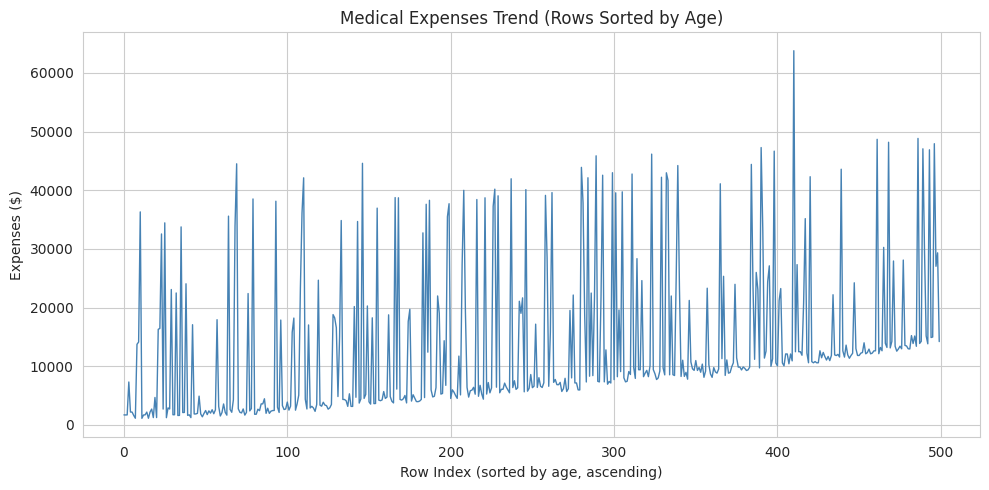

In [15]:
df_sorted = df.sort_values('age').reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(df_sorted.index, df_sorted['expenses'], color='steelblue', linewidth=1)
plt.title('Medical Expenses Trend (Rows Sorted by Age)')
plt.xlabel('Row Index (sorted by age, ascending)')
plt.ylabel('Expenses ($)')
plt.tight_layout()
plt.show()

### 7.2 Bar chart — mean expenses by region

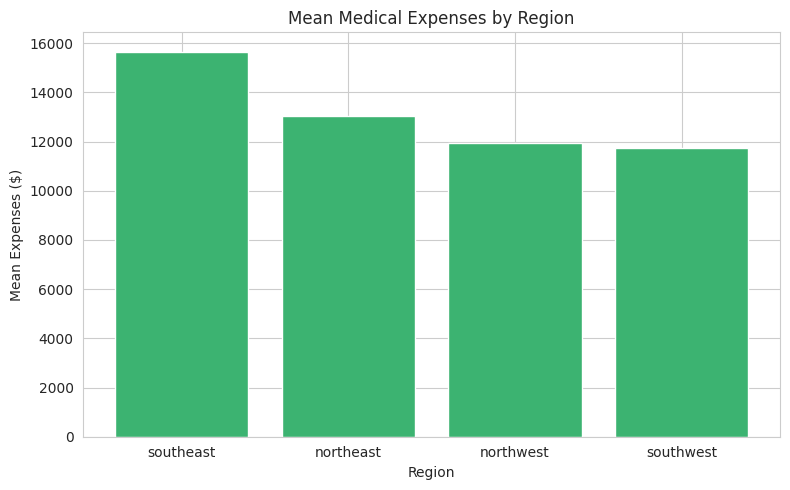

In [16]:
region_means = df.groupby('region', observed=True)['expenses'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_means.index, region_means.values, color='mediumseagreen')
plt.title('Mean Medical Expenses by Region')
plt.xlabel('Region')
plt.ylabel('Mean Expenses ($)')
plt.tight_layout()
plt.show()

### 7.3 Histogram — distribution of the most skewed column (`expenses`)

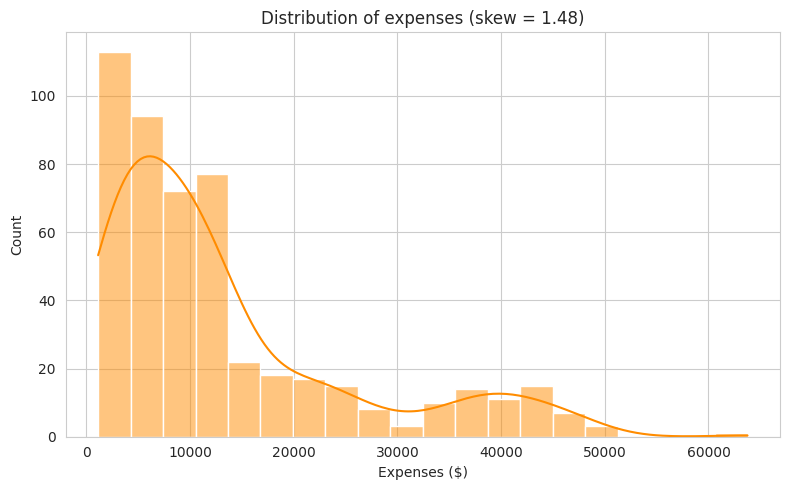

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['expenses'], bins=20, kde=True, color='darkorange')
plt.title(f'Distribution of {most_skewed_col} (skew = {skew_report.iloc[0]:.2f})')
plt.xlabel('Expenses ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 7.4 Scatter plot — age vs. expenses

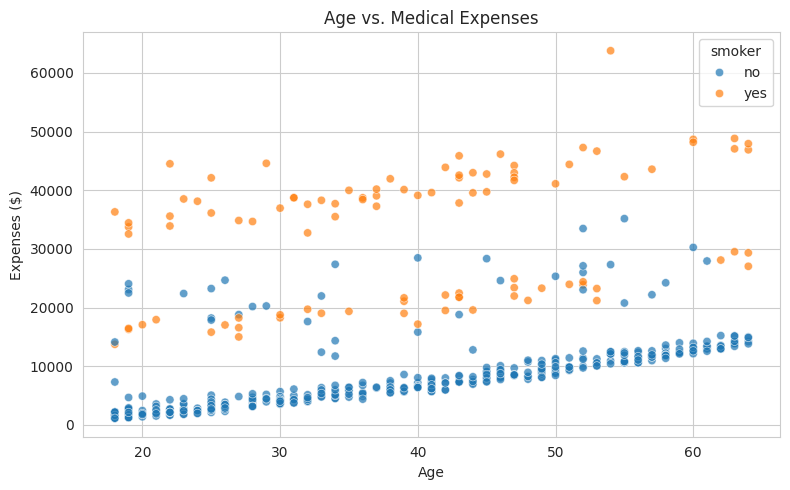

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='expenses', hue='smoker', alpha=0.7)
plt.title('Age vs. Medical Expenses')
plt.xlabel('Age')
plt.ylabel('Expenses ($)')
plt.tight_layout()
plt.show()

### 7.5 Box plot — expenses by smoker status

/tmp/ipykernel_535/2563452434.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='expenses', palette='Set2')


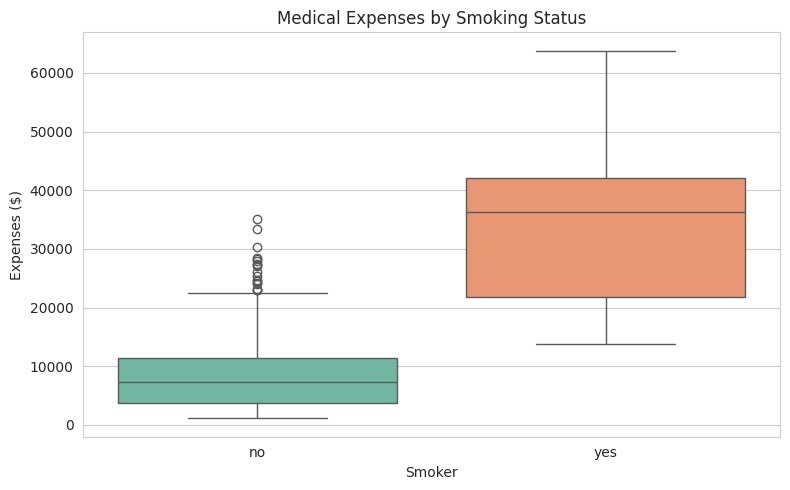

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='expenses', palette='Set2')
plt.title('Medical Expenses by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Expenses ($)')
plt.tight_layout()
plt.show()

### 7.6 Correlation heat map

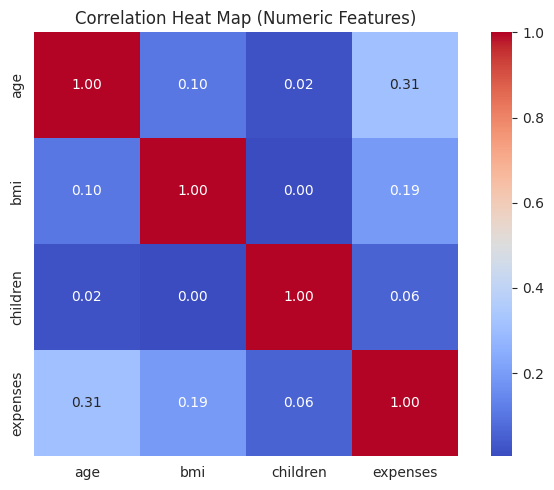

,age,bmi,children,expenses
age,1.000000,0.103439,0.017017,0.310505
bmi,0.103439,1.000000,0.004842,0.194674
children,0.017017,0.004842,1.000000,0.059136
expenses,0.310505,0.194674,0.059136,1.000000


In [20]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heat Map (Numeric Features)')
plt.tight_layout()
plt.show()

corr_matrix

In [21]:
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print("Highest-correlation pair:", corr_pairs.index[0], "->", corr_pairs.iloc[0].round(3))

Highest-correlation pair: ('age', 'expenses') -> 0.311


## Task 8a — Imputation strategy comparison (mean vs. median)

Applied to the two highest-|skew| numeric columns: `expenses` and `children`.

In [22]:
top2_skew_cols = skew_report.index[:2].tolist()
print("Two highest-skew columns:", top2_skew_cols)

for col in top2_skew_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean = {mean_val:.2f} | median = {median_val:.2f}")

Two highest-skew columns: ['expenses', 'children']
expenses: mean = 13179.46 | median = 9238.70
children: mean = 1.10 | median = 1.00


In [23]:
# Apply chosen imputation strategy (median, for both columns — see README) to any remaining nulls
for col in top2_skew_cols:
    df[col] = df[col].fillna(df[col].median())

print("Nulls remaining in these columns after imputation:")
df[top2_skew_cols].isnull().sum()

Nulls remaining in these columns after imputation:


expenses    0
children    0
dtype: int64

## Task 8b — Spearman rank correlation vs. Pearson

In [24]:
spearman_matrix = df[numeric_cols].corr(method='spearman')
pearson_matrix = corr_matrix  # from Task 7.6

print("Pearson:")
display(pearson_matrix)
print("\nSpearman:")
display(spearman_matrix)

Pearson:


,age,bmi,children,expenses
age,1.000000,0.103439,0.017017,0.310505
bmi,0.103439,1.000000,0.004842,0.194674
children,0.017017,0.004842,1.000000,0.059136
expenses,0.310505,0.194674,0.059136,1.000000



Spearman:


,age,bmi,children,expenses
age,1.000000,0.104784,0.026590,0.569713
bmi,0.104784,1.000000,-0.000907,0.107273
children,0.026590,-0.000907,1.000000,0.141205
expenses,0.569713,0.107273,0.141205,1.000000


In [25]:
diff_matrix = (spearman_matrix - pearson_matrix).abs()
print("|Spearman - Pearson| difference table:")
display(diff_matrix)

pairs = []
cols = numeric_cols
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append({
            'pair': f"{cols[i]} - {cols[j]}",
            'pearson': pearson_matrix.iloc[i, j],
            'spearman': spearman_matrix.iloc[i, j],
            'abs_diff': diff_matrix.iloc[i, j],
        })

pairs_df = pd.DataFrame(pairs).sort_values('abs_diff', ascending=False).reset_index(drop=True)
print("\nTop 3 pairs by |Spearman - Pearson|:")
pairs_df.head(3)

|Spearman - Pearson| difference table:


,age,bmi,children,expenses
age,0.000000,0.001345,0.009573,0.259208
bmi,0.001345,0.000000,0.005749,0.087401
children,0.009573,0.005749,0.000000,0.082068
expenses,0.259208,0.087401,0.082068,0.000000



Top 3 pairs by |Spearman - Pearson|:


,pair,pearson,spearman,abs_diff
0,age - expenses,0.310505,0.569713,0.259208
1,bmi - expenses,0.194674,0.107273,0.087401
2,children - expenses,0.059136,0.141205,0.082068


## Task 8c — Grouped aggregation

Categorical column: `smoker`. Numeric column: `expenses`.

In [26]:
group_stats = df.groupby('smoker', observed=True)['expenses'].agg(['mean', 'std', 'count'])
group_stats

,mean,std,count
smoker,,,
no,8350.441418,5992.570474,402
yes,32988.304898,11027.047827,98


In [27]:
highest_mean_group = group_stats['mean'].idxmax()
highest_std_group = group_stats['std'].idxmax()
mean_ratio = group_stats['mean'].max() / group_stats['mean'].min()

print(f"Highest mean group: {highest_mean_group} (${group_stats['mean'].max():.2f})")
print(f"Highest std group:  {highest_std_group} (${group_stats['std'].max():.2f})")
print(f"Ratio of highest to lowest group mean: {mean_ratio:.2f}x")

Highest mean group: yes ($32988.30)
Highest std group:  yes ($11027.05)
Ratio of highest to lowest group mean: 3.95x


## Save cleaned dataset

In [28]:
df.to_csv('cleaned_data.csv', index=False)
print("Saved cleaned_data.csv with shape:", df.shape)

Saved cleaned_data.csv with shape: (500, 7)
